World Cup 2026 Predictor

A ML project that predicts the outcomes of FIFA World Cup 2026 matches and simulates the tournament bracket to crown a predicted winner from player performance data.

The dataset contains per-player, per-match performance statistics (~54,600 rows, 75 features). To predict match outcomes, individual player rows are aggregated up to the team-vs-team match level, then a classifier is trained to predict the result.

In [1]:
!pip install kagglehub
!pip install seaborn
!pip install shap

import os
import pandas as pd
import numpy as np
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">1. Beginning</span>

</div>

In [2]:
import kagglehub
import os

folder = kagglehub.dataset_download("martj42/international-football-results-from-1872-to-2017")
print(os.listdir(folder))

['goalscorers.csv', 'shootouts.csv', 'results.csv', 'former_names.csv']


In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "results.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "martj42/international-football-results-from-1872-to-2017",
    file_path,
)

df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">2. Data Splitting</span>

I split the data into 70% training data and 30% test data with random_state = 123

</div>

In [4]:
df['result'] = np.select(
    [df['home_score'] > df['away_score'], df['home_score'] < df['away_score']],
    ['home_win', 'away_win'], default='draw')

train_df, test_df = train_test_split(df, test_size=0.3, random_state=123)

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">3. EDA</span>

I did an exploratory data analysis (EDA) where I conducted an initial exploration of the training set to better understand its characteristics.

Then I summarized the data and included two summary statistics and two visualizations that I found informative and I wrote what insight it provided.

After that, I summarized my initial observations about the dataset based on my EDA.

Lastly, I selected evaluation metrics that's appropriate metrics for assessing model performance and justified my choice.
</div>

In [5]:
print(train_df.shape)
train_df.info()
train_df.head()

print(train_df['date'].min(), "to", train_df['date'].max())
print(train_df['tournament'].nunique(), "tournament types")

(34633, 10)
<class 'pandas.core.frame.DataFrame'>
Index: 34633 entries, 48195 to 15725
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        34633 non-null  object 
 1   home_team   34633 non-null  object 
 2   away_team   34633 non-null  object 
 3   home_score  34603 non-null  float64
 4   away_score  34603 non-null  float64
 5   tournament  34633 non-null  object 
 6   city        34633 non-null  object 
 7   country     34633 non-null  object 
 8   neutral     34633 non-null  bool   
 9   result      34633 non-null  object 
dtypes: bool(1), float64(2), object(7)
memory usage: 2.7+ MB
1872-11-30 to 2026-06-27
198 tournament types


1. The training set has 34633 matches and 9 columns, spanning from 1872 to 2026. Each row is one international match with the two teams, the score, and context (tournament, city, whether it was on neutral ground)

In [6]:
print(train_df['result'].value_counts(normalize=True))

print(train_df[['home_score', 'away_score']].mean())

result
home_win    0.489937
away_win    0.283140
draw        0.226922
Name: proportion, dtype: float64
home_score    1.761957
away_score    1.183828
dtype: float64


2 summary stats: A) Home wins are the most common outcome with 48.9937%, draws the least — showing a clear home-field advantage that the model should be able to learn and B) Home teams score more goals on average than away teams (1.76 vs 1.18 goals).

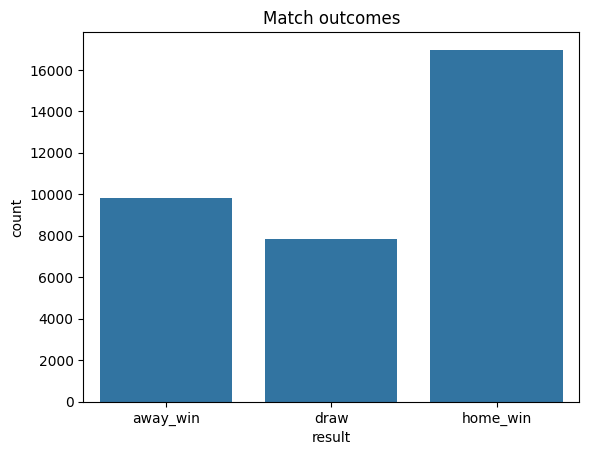

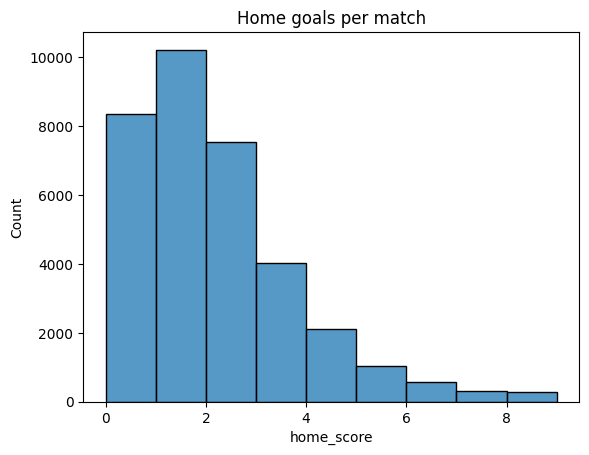

In [7]:
import seaborn as sns, matplotlib.pyplot as plt
sns.countplot(x='result', data=train_df)
plt.title('Match outcomes'); plt.show()

sns.histplot(train_df['home_score'], bins=range(0,10))
plt.title('Home goals per match'); plt.show()

To summarize my findings:
- There's a clear home-field advantage (home wins most common and home teams score more).
- Three outcome classes (home_win / away_win / draw), and they're imbalanced (draws rarest).
- Since the raw data is thin (just has teams, scores, and context), I'll need to engineer features (team strength, recent form) since there's no features like player ratings in the dataset
- Data spans 150+ years; older matches may be less relevant to modern prediction.

This is a 3-class classification problem with imbalanced classes, so:

- I'll use accuracy as a headline number but rely on macro-averaged F1 as the main metric. Because the classes are imbalanced (draws are rare), accuracy can be inflated by always predicting the majority class (home win). Macro-F1 weights all three outcomes equally, so it better reflects whether the model handles draws and away wins too. 
- I'll also compare against a DummyClassifier baseline to confirm the model beats naive guessing

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">4. Feature Engineering</span>

I created new features that are relevant to the problem and use this updated feature later on in my project.

Here's what I did:
1. I split every match into two rows — one from each team's point of view. Now I have a list like "Spain: scored 2, won" / "Canada: scored 0, lost."

2. For each team, I look at their previous 10 matches and average them: win rate, goals scored, goals conceded. I only count games that happened BEFORE the current match (the shift(1)), because in real life you can't know future results when predicting.

3. I attached those numbers back onto the original match. So the Spain-vs-Canada row gets two new sets of columns: Spain's recent form and Canada's recent form.

4. I compare the two teams and the single most useful feature is the difference: Spain's form minus Canada's form. A big positive number = home team much stronger = likely home win. --> Column that does the prediction

</div>

In [8]:
# Work on the FULL df sorted by date, THEN split later (form needs history in order)
df = df.sort_values('date').reset_index(drop=True)

# 1. Reshape to one row per TEAM per match to track each team's history
home = df[['date','home_team','home_score','away_score']].rename(
    columns={'home_team':'team','home_score':'gf','away_score':'ga'})
away = df[['date','away_team','away_score','home_score']].rename(
    columns={'away_team':'team','away_score':'gf','home_score':'ga'})
long = pd.concat([home, away]).sort_values('date')

long['win']    = (long['gf'] > long['ga']).astype(int)
long['points'] = np.select([long.gf > long.ga, long.gf == long.ga], [3, 1], 0)

# 2. Rolling form over each team's PREVIOUS 10 matches (shift(1) = exclude current match)
N = 10
long = long.sort_values(['team','date'])
for col, new in [('win','form_winrate'), ('gf','form_gf'), ('ga','form_ga'), ('points','form_pts')]:
    long[new] = (long.groupby('team')[col]
                     .transform(lambda s: s.shift(1).rolling(N, min_periods=1).mean()))

# 3. Merge each team's form back onto the match (once for home, once for away)
form_cols = ['form_winrate','form_gf','form_ga','form_pts']
form = long[['date','team'] + form_cols]

df = df.merge(form.add_prefix('home_'), left_on=['date','home_team'],
              right_on=['home_date','home_team'], how='left').drop(columns='home_date')
df = df.merge(form.add_prefix('away_'), left_on=['date','away_team'],
              right_on=['away_date','away_team'], how='left').drop(columns='away_date')

# 4. The features that actually predict the winner: the DIFFERENCE in strength
df['winrate_diff'] = df['home_form_winrate'] - df['away_form_winrate']
df['gf_diff']      = df['home_form_gf']      - df['away_form_gf']
df['form_pts_diff']= df['home_form_pts']     - df['away_form_pts']

df[['home_team','away_team','winrate_diff','form_pts_diff','result']].head(15)

,home_team,away_team,winrate_diff,form_pts_diff,result
0,Scotland,England,NaN,NaN,draw
1,England,Scotland,0.000000,0.000000,home_win
2,Scotland,England,-0.500000,-1.500000,home_win
3,England,Scotland,0.000000,0.000000,draw
4,Scotland,England,0.000000,0.000000,home_win
5,Scotland,Wales,NaN,NaN,home_win
6,England,Scotland,-0.300000,-0.833333,away_win
7,Wales,Scotland,-0.571429,-2.000000,away_win
8,Scotland,England,0.458333,1.291667,home_win
9,Scotland,Wales,0.666667,2.222222,home_win


<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">5. Preprocessing and transformations</span>

A) Identify feature types: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

B) Define a column transformer (if needed): Implement a ColumnTransformer to apply the appropriate preprocessing steps to each feature type.
</div>

In [9]:
numerical_features = ['winrate_diff', 'form_pts_diff']

categorical_features = ['home_team', 'away_team'] ## REMOVE RESULT FROM CATEGORICAL FEATURE BC ITS TARGET!!!

preprocessor = make_column_transformer(
    (StandardScaler(), numerical_features),
    (OneHotEncoder(), categorical_features),
)

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">6. Baseline Model</span>

I used the DummyClassifier as my basline and this will serve as a reference point for evaluating the performance of my more advanced models later on.

</div>

In [10]:
X_train = train_df.drop(columns=["result"])
y_train = train_df["result"]
X_test  = test_df.drop(columns=["result"])
y_test  = test_df["result"]

train_df, test_df = train_test_split(df, test_size=0.3, random_state=123)

from sklearn.metrics import classification_report
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

y_pred = dummy_clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    away_win       0.00      0.00      0.00      4157
        draw       0.00      0.00      0.00      3428
    home_win       0.49      1.00      0.66      7259

    accuracy                           0.49     14844
   macro avg       0.16      0.33      0.22     14844
weighted avg       0.24      0.49      0.32     14844



/Users/sabrinayuan/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sabrinayuan/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sabrinayuan/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

My Dummy model is 49% correct when always predicting that home team will win and has an average f1 score of 0.66 

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">7. Linear Models</span>

Train a linear model: Use a linear model as your first real attempt at solving the problem.

Tune hyperparameters: Perform hyperparameter tuning to explore different values of the model's complexity parameter.

Evaluate with cross-validation: Report the cross-validation scores along with their standard deviation.

Summarize findings: Summarize your results, highlighting key observations from your experiments.

</div>

In [14]:
from sklearn.pipeline import make_pipeline

X = train_df.drop(columns=['result'])
y = train_df['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

pipeline = make_pipeline(preprocessor, LogisticRegression(max_iter=1000, random_state=123))

In [15]:
print('winrate_diff' in df.columns)        # probably True
print('winrate_diff' in X_train.columns)   # probably False  ← the problem

True
True


In [16]:
param_grid = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100]
}

gs = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

gs.fit(X_train, y_train)

ValueError: 
All the 25 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/sabrinayuan/miniforge3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/sabrinayuan/miniforge3/lib/python3.12/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sabrinayuan/miniforge3/lib/python3.12/site-packages/sklearn/pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/Users/sabrinayuan/miniforge3/lib/python3.12/site-packages/sklearn/base.py",

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">8. Different Models</span>

A) Experiment with additional models: Train at least three models other than a linear model. Ensure that at least one of these models is a tree-based ensemble model (e.g., Random Forest, Gradient Boosting, or XGBoost).

B) Compare and interpret results: Summarize your findings in terms of overfitting/underfitting behavior and fit/score times for each model. Reflect on your results. Were you able to outperform the linear model?
</div>

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">9. Feature Selection</span>

A) Perform feature selection: Attempt to select relevant features using methods such as RFECV or forward selection.

B) Evaluate the impact Compare the model performance before and after feature selection. Do the results improve with feature selection?

C) Summarize findings Summarize your observations and decide whether to keep feature selection in your pipeline. If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">10. Hyperparameter Optimization</span>

A) Optimize hyperparameters: Attempt to optimize hyperparameters for the models you have tried so far. In at least one case, tune multiple hyperparameters for a single model.

B) Use suitable optimization methods: You may use any of the following approaches for hyperparameter optimization:
- GridSearchCV
- RandomizedSearchCV
- Bayesian optimization with scikit-optimize

C) Summarize your results: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.
</div>

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">11. Interpretation and feature importances</span>

A) Interpret model feature importance: Use one of the interpretation methods discussed in class (e.g., shap), or another suitable method of your choice, to examine the most important features of one of your non-linear models.

B) Summarize insights: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.
</div>

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">12. Results on the test set</span>

A) Evaluate on the test set: Apply your best-performing model to the test data and report the test scores.

B) Compare and reflect: Compare the test scores with the validation scores from previous experiments. Discuss the consistency between them. How much do you trust your results? Reflect on whether you might have encountered optimization bias.

C) Explain individual predictions: Select one or two examples from your test predictions and use an interpretation method (e.g., SHAP force plots) to explain these individual predictions.
</div>

<div style="background-color: #333333; color: #FFFFFF; padding: 15px; border-radius: 5px;">
<span style="font-size: 24px;">13. Summary</span>

A) Summarize key results: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

B) Write concluding remarks: Summarize your main takeaways from the project, including what worked well and what did not.

C) Propose future improvements: Discuss ideas or approaches you did not try but that could potentially improve performance or interpretability.

Report final results: Report your final test score and the metric you used.
</div>